<a href="https://colab.research.google.com/github/justsaymel/telecomx_1/blob/main/TelecomX_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracción

In [1]:
import pandas as pd

In [2]:
url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json'
df = pd.read_json(url)

In [3]:
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#🔧 Transformación

In [4]:
customer_datos = df['customer'].tolist()

In [5]:
df_customer = pd.json_normalize(customer_datos)

In [6]:
df_phone = pd.json_normalize(df['phone'].tolist())
df_internet = pd.json_normalize(df['internet'].tolist())
df_account = pd.json_normalize(df['account'].tolist())

In [7]:
df_final = pd.concat(
    [
        df[['customerID', 'Churn']],
        df_customer,
        df_phone,
        df_internet,
        df_account
    ],
    axis=1
)

In [8]:
df_final.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [9]:
df_final.columns

Index(['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly',
       'Charges.Total'],
      dtype='object')

In [10]:
df_final['Cuentas_diarias'] = df_final['Charges.Monthly'] / 30
df_final['Cuentas_diarias'] = df_final['Cuentas_diarias'].round(2)
df_final.sample(10)

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_diarias
2761,3812-LRZIR,No,Female,0,Yes,Yes,27,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Electronic check,24.50,761.95,0.82
1531,2195-ZRVAX,Yes,Female,0,Yes,No,47,Yes,No,Fiber optic,...,Yes,No,No,Yes,Month-to-month,Yes,Electronic check,85.30,4045.65,2.84
3967,5424-RLQLC,No,Male,0,No,No,10,Yes,No,DSL,...,No,No,Yes,No,Month-to-month,Yes,Mailed check,59.65,638.95,1.99
783,1104-TNLZA,No,Male,1,Yes,No,28,Yes,Yes,Fiber optic,...,No,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,105.80,2998,3.53
5258,7169-YWAMK,No,Male,0,Yes,Yes,72,Yes,No,DSL,...,No,Yes,Yes,No,Two year,No,Bank transfer (automatic),68.40,4855.35,2.28
1200,1710-RCXUS,No,Male,0,Yes,No,51,Yes,Yes,Fiber optic,...,No,No,No,Yes,One year,Yes,Credit card (automatic),90.35,4614.55,3.01
5169,7054-LGEQW,Yes,Female,0,No,No,1,Yes,No,DSL,...,No,No,No,No,Month-to-month,No,Mailed check,45.95,45.95,1.53
4776,6543-XRMYR,Yes,Female,1,No,No,30,Yes,Yes,Fiber optic,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.70,2967.35,3.32
476,0674-GCDXG,No,Male,0,No,No,63,Yes,Yes,DSL,...,Yes,Yes,No,Yes,Two year,Yes,Bank transfer (automatic),71.90,4479.2,2.40
3515,4844-JJWUY,Yes,Female,1,No,No,1,Yes,No,Fiber optic,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,86.00,86,2.87


In [11]:
columnas_binarias = [
    'Churn', 'Partner', 'Dependents', 'PhoneService',
    'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV',
    'StreamingMovies', 'PaperlessBilling'
]

In [12]:
for columna in columnas_binarias:
    print(f"{columna}: {df_final[columna].unique()}")

Churn: ['No' 'Yes' '']
Partner: ['Yes' 'No']
Dependents: ['Yes' 'No']
PhoneService: ['Yes' 'No']
MultipleLines: ['No' 'Yes' 'No phone service']
OnlineSecurity: ['No' 'Yes' 'No internet service']
OnlineBackup: ['Yes' 'No' 'No internet service']
DeviceProtection: ['No' 'Yes' 'No internet service']
TechSupport: ['Yes' 'No' 'No internet service']
StreamingTV: ['Yes' 'No' 'No internet service']
StreamingMovies: ['No' 'Yes' 'No internet service']
PaperlessBilling: ['Yes' 'No']


In [13]:
for columna in columnas_binarias:
    df_final[columna] = df_final[columna].astype(str).apply(lambda x: 1 if x == 'Yes' else 0)

print(df_final[columnas_binarias].head())

   Churn  Partner  Dependents  PhoneService  MultipleLines  OnlineSecurity  \
0      0        1           1             1              0               0   
1      0        0           0             1              1               0   
2      1        0           0             1              0               0   
3      1        1           0             1              0               0   
4      1        1           0             1              0               0   

   OnlineBackup  DeviceProtection  TechSupport  StreamingTV  StreamingMovies  \
0             1                 0            1            1                0   
1             0                 0            0            0                1   
2             0                 1            0            0                0   
3             1                 1            0            1                1   
4             0                 0            1            1                0   

   PaperlessBilling  
0                 1  
1     

In [14]:
df_final.sample(10)

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_diarias
784,1106-HRLKZ,0,Male,0,1,1,40,1,0,No,...,0,0,0,0,Two year,0,Mailed check,19.60,808.95,0.65
4848,6633-MPWBS,1,Male,0,0,0,5,1,0,DSL,...,0,1,0,0,Month-to-month,1,Electronic check,49.20,216.9,1.64
6872,9483-GCPWE,0,Male,0,0,1,9,1,0,No,...,0,0,0,0,One year,0,Mailed check,20.10,190.25,0.67
2304,3209-ZPKFI,0,Male,0,1,1,47,1,1,DSL,...,0,0,0,0,Month-to-month,0,Electronic check,54.25,2538.2,1.81
1298,1866-NXPSP,0,Female,0,0,0,36,1,0,DSL,...,1,1,0,1,One year,1,Mailed check,75.55,2680.15,2.52
4396,6022-MXOMF,0,Female,1,0,0,1,1,1,Fiber optic,...,0,0,0,0,Month-to-month,1,Electronic check,74.20,74.2,2.47
6275,8631-NBHFZ,1,Male,1,1,1,66,1,1,DSL,...,1,1,1,0,Two year,0,Credit card (automatic),79.40,5154.6,2.65
3539,4879-GZLFH,0,Female,0,1,1,42,1,0,Fiber optic,...,1,0,1,1,Month-to-month,1,Electronic check,92.15,3875.4,3.07
6199,8510-BBWMU,0,Female,0,0,0,41,1,0,No,...,0,0,0,0,One year,1,Mailed check,19.75,806.95,0.66
4332,5949-EBSQK,1,Male,0,1,1,4,1,0,DSL,...,0,1,0,1,Month-to-month,0,Credit card (automatic),61.45,229.55,2.05


In [47]:
df_final.value_counts('Churn')

,count
Churn,
0,5398
1,1869


#📊 Carga y análisis

In [15]:
df_final.describe()

,Churn,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,Charges.Monthly,Cuentas_diarias
count,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000
mean,0.257190,0.162653,0.484106,0.300124,32.346498,0.902711,0.421770,0.285950,0.344571,0.342782,0.289528,0.383927,0.387505,0.593230,64.720098,2.157292
std,0.437115,0.369074,0.499782,0.458343,24.571773,0.296371,0.493876,0.451897,0.475261,0.474672,0.453575,0.486374,0.487214,0.491265,30.129572,1.004407
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.610000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,35.425000,1.180000
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,70.300000,2.340000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.875000,2.995000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,118.750000,3.960000


In [16]:
import warnings
warnings.filterwarnings('ignore')

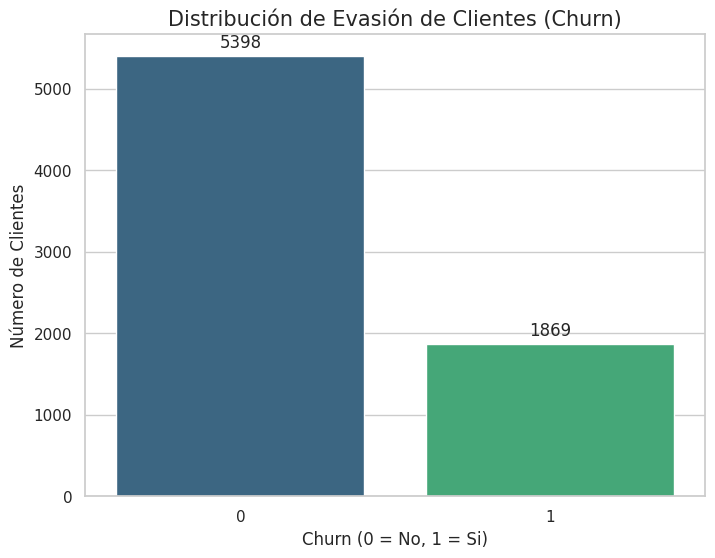

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='Churn', data=df_final, palette='viridis')
plt.title('Distribución de Evasión de Clientes (Churn)', fontsize=15)
plt.xlabel('Churn (0 = No, 1 = Si)', fontsize=12)
plt.ylabel('Número de Clientes', fontsize=12)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center', xytext = (0, 10), textcoords = 'offset points')

plt.savefig('distribucion_churn.png', dpi=300, bbox_inches='tight')
plt.show()

In [18]:
print(df_final.groupby('Contract')['Churn'].mean() * 100)

Contract
Month-to-month    41.323346
One year          10.928242
Two year           2.753873
Name: Churn, dtype: float64


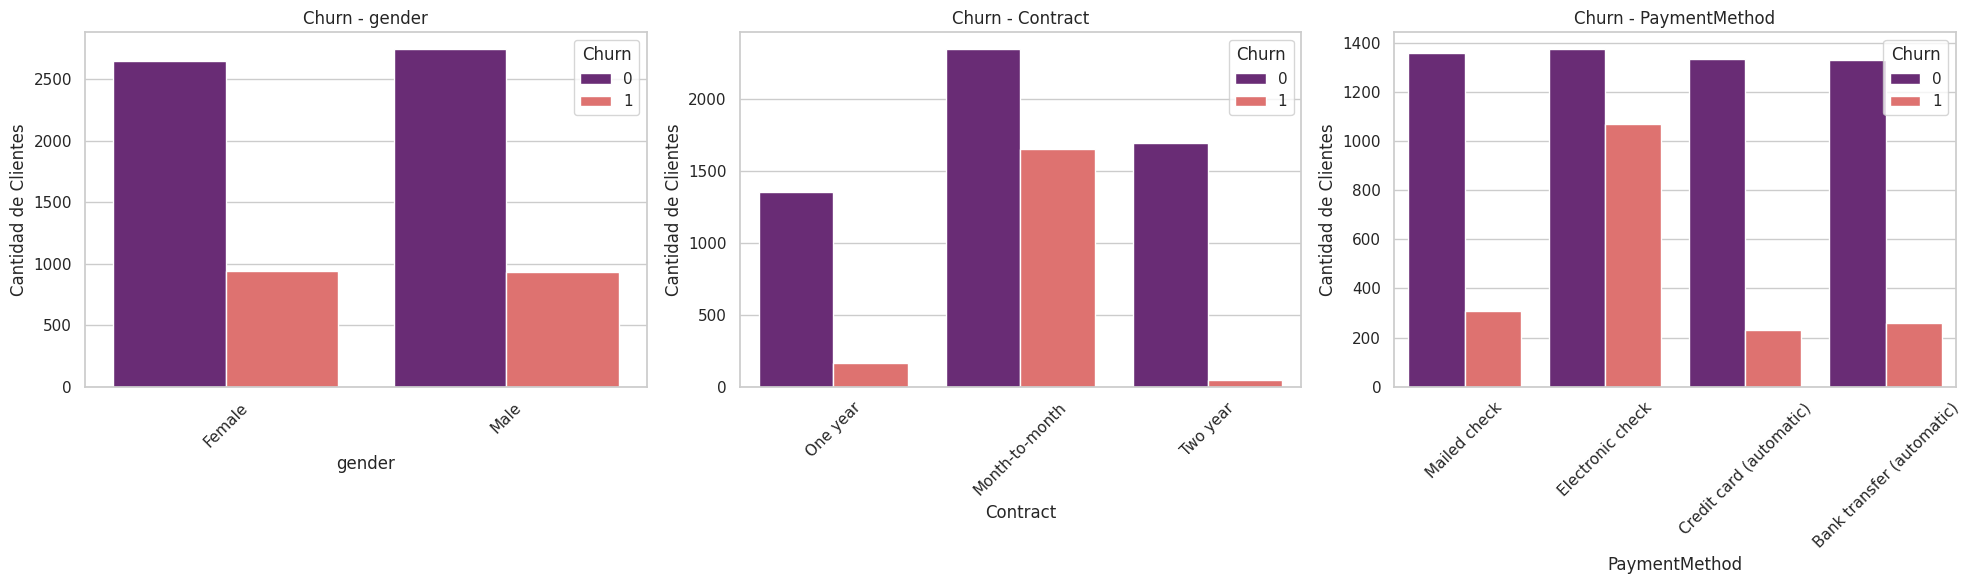

In [36]:
variables_categoricas = ['gender', 'Contract', 'PaymentMethod']

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 6))

for i, col in enumerate(variables_categoricas):
    sns.countplot(x=col, hue='Churn', data=df_final, ax=axes[i], palette='magma')
    axes[i].set_title(f'Churn - {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Cantidad de Clientes')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('variables_categoricas.png', dpi=300, bbox_inches='tight')
plt.show()

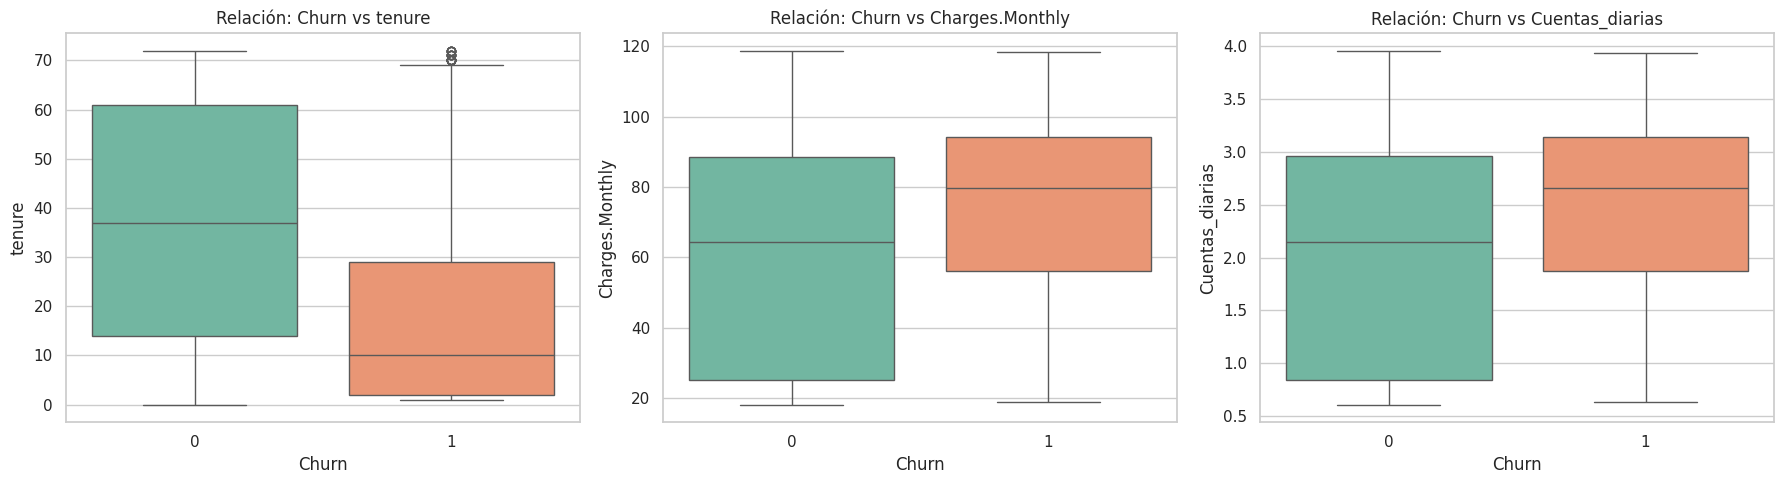

In [37]:
cols_numericas = ['tenure', 'Charges.Monthly', 'Cuentas_diarias']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(cols_numericas):
    sns.boxplot(x='Churn', y=col, data=df_final, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Relación: Churn vs {col}')

plt.tight_layout()
plt.savefig('variables_numericas.png', dpi=300, bbox_inches='tight')
plt.show()

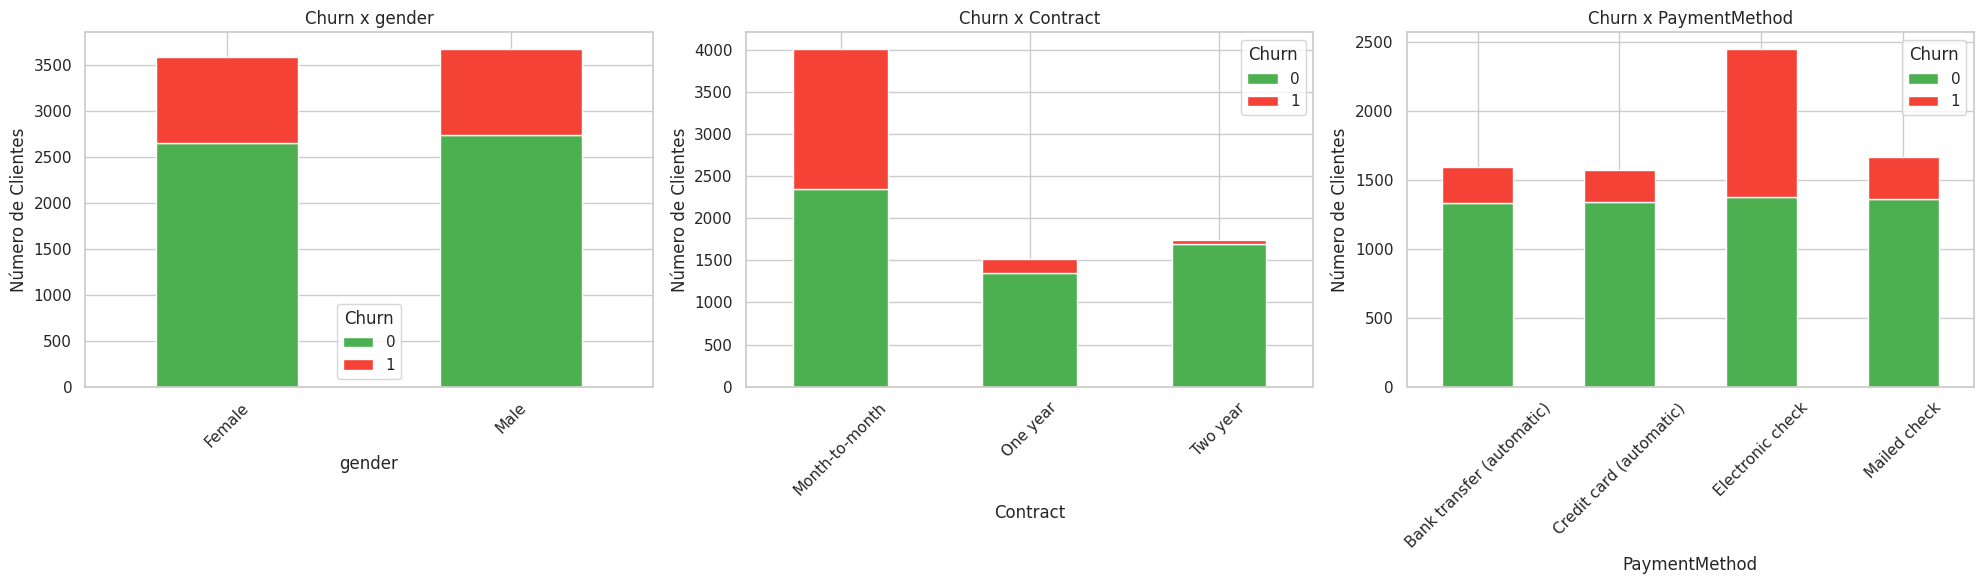

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, col in enumerate(variables_categoricas):
    pd.crosstab(df_final[col], df_final['Churn']).plot(kind='bar', stacked=True, ax=axes[i], color=['#4CAF50', '#F44336'])

    axes[i].set_title(f'Churn x {col}')
    axes[i].set_ylabel('Número de Clientes')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('numericas_barras.png', dpi=300, bbox_inches='tight')
plt.show()

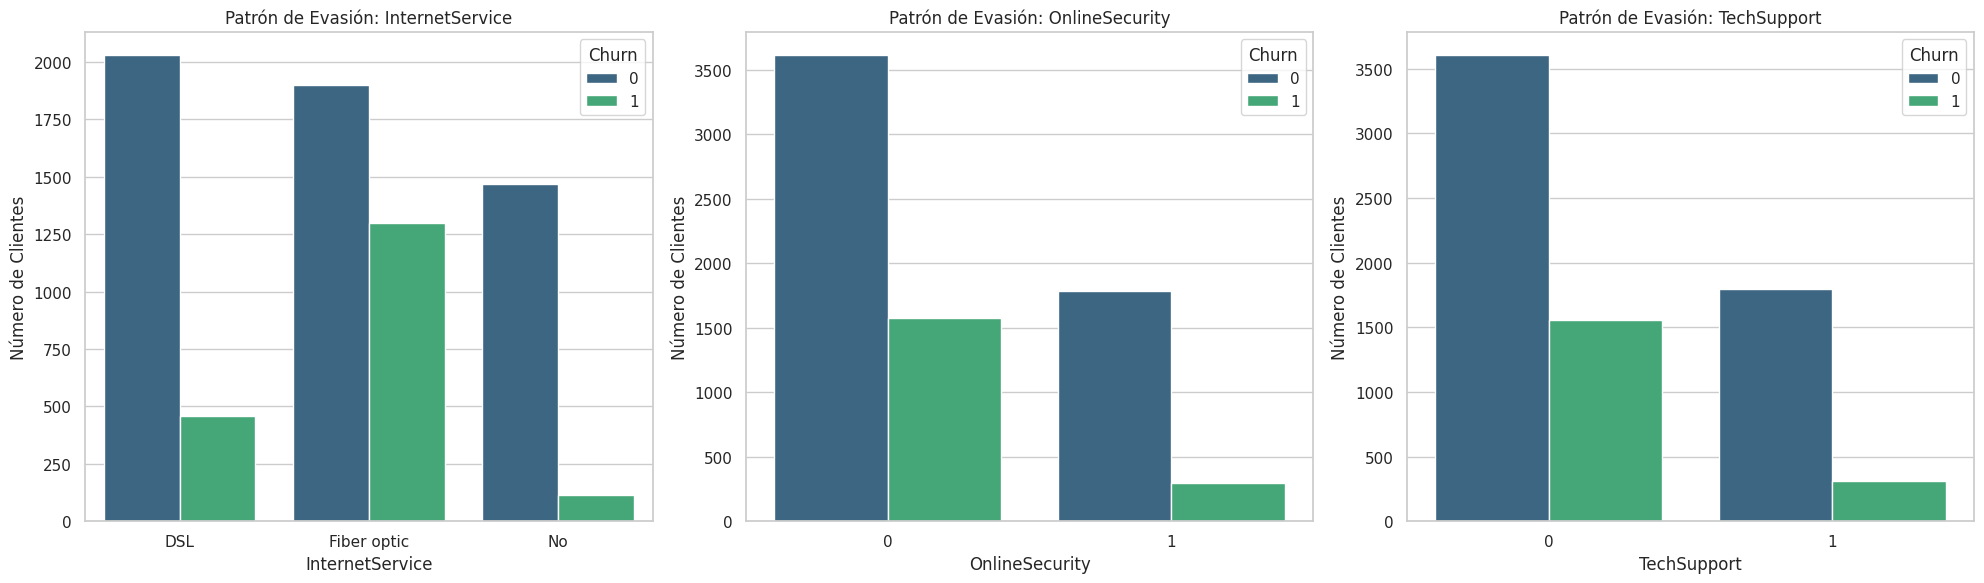

In [39]:
servicios = ['InternetService', 'OnlineSecurity', 'TechSupport']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, col in enumerate(servicios):
    sns.countplot(x=col, hue='Churn', data=df_final, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Patrón de Evasión: {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Número de Clientes')
    axes[i].tick_params(axis='x')

plt.tight_layout()
plt.savefig('servicios.png', dpi=300, bbox_inches='tight')
plt.show()

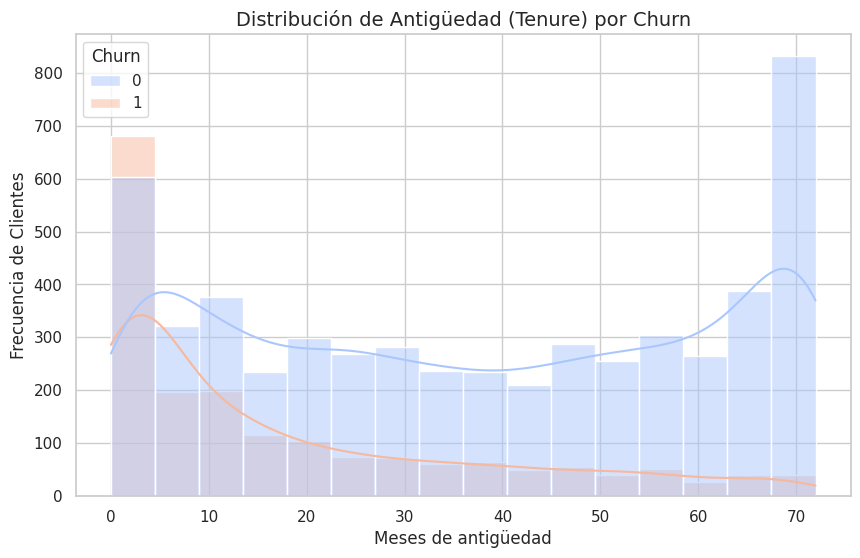

In [40]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df_final, x='tenure', hue='Churn', kde=True,
             palette='coolwarm')

plt.title('Distribución de Antigüedad (Tenure) por Churn', fontsize=14)
plt.xlabel('Meses de antigüedad')
plt.ylabel('Frecuencia de Clientes')

plt.savefig('distribucion_tenure.png', dpi=300, bbox_inches='tight')
plt.show()

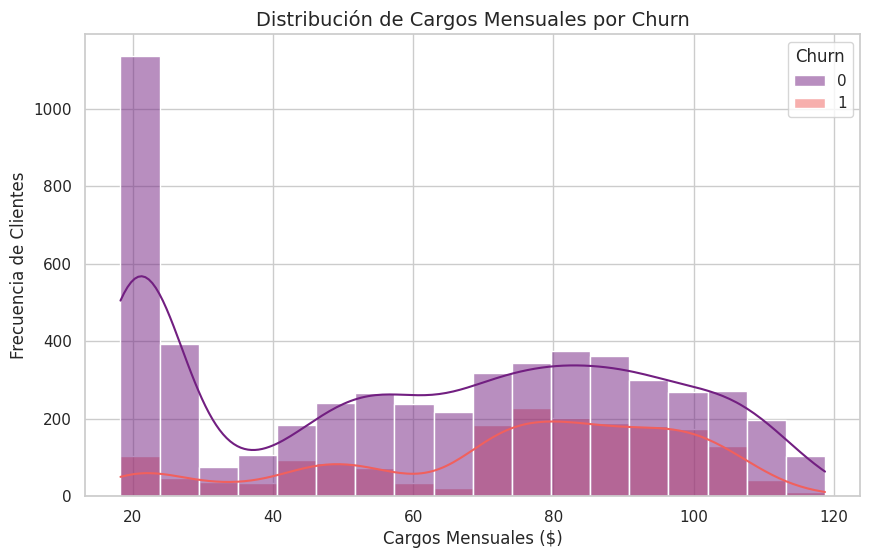

In [41]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df_final, x='Charges.Monthly', hue='Churn', kde=True,
            palette='magma')

plt.title('Distribución de Cargos Mensuales por Churn', fontsize=14)
plt.xlabel('Cargos Mensuales ($)')
plt.ylabel('Frecuencia de Clientes')

plt.savefig('distribucion_mensual.png', dpi=300, bbox_inches='tight')
plt.show()

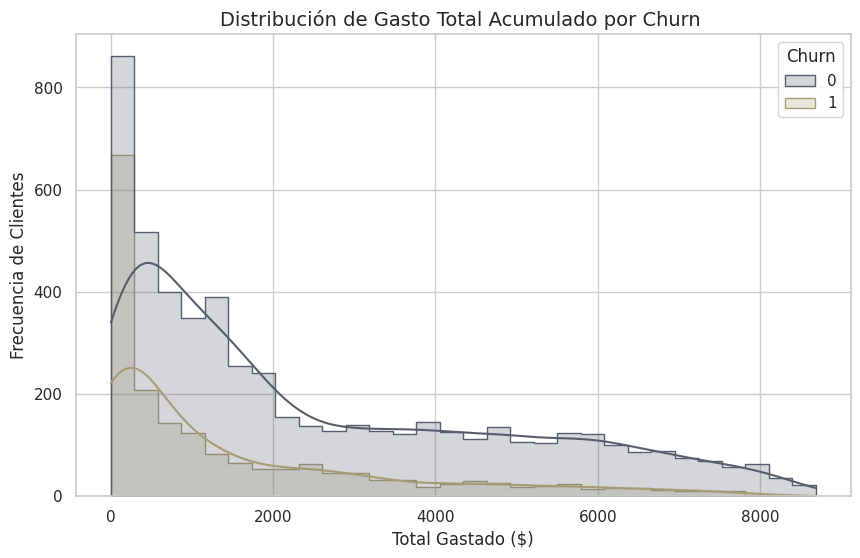

In [42]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df_final, x='Charges.Total', hue='Churn', kde=True,
             element="step", palette='cividis', bins=30, fill=True)

plt.title('Distribución de Gasto Total Acumulado por Churn ', fontsize=14)
plt.xlabel('Total Gastado ($)')
plt.ylabel('Frecuencia de Clientes')

plt.savefig('distribucion_gasto_total.png', dpi=300, bbox_inches='tight')
plt.show()

In [26]:
columnas_resumen = ['tenure', 'Charges.Monthly', 'Charges.Total', 'Cuentas_diarias']

for col in columnas_resumen:
    df_final[col] = pd.to_numeric(df_final[col], errors='coerce')

df_final[columnas_resumen] = df_final[columnas_resumen].fillna(0)
resumen_numerico = df_final.groupby('Churn')[columnas_resumen].mean()

print("Promedios por grupo:")
print(resumen_numerico)

Promedios por grupo:
          tenure  Charges.Monthly  Charges.Total  Cuentas_diarias
Churn                                                            
0      37.321045        61.354224    2535.263977         2.045056
1      17.979133        74.441332    1531.796094         2.481450


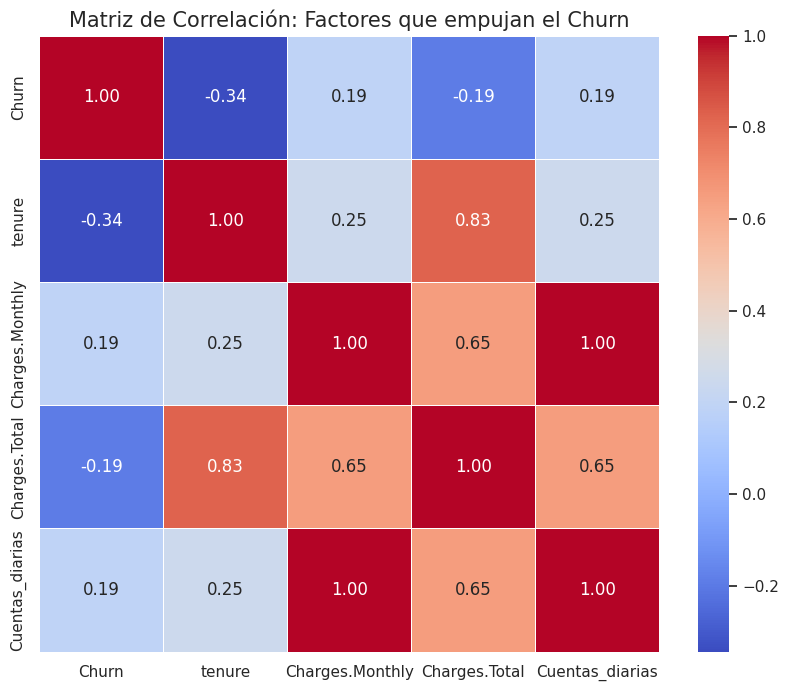

In [43]:
columnas_corr = ['Churn', 'tenure', 'Charges.Monthly', 'Charges.Total', 'Cuentas_diarias']
matriz_correlacion = df_final[columnas_corr].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación: Factores que empujan el Churn', fontsize=15)

plt.savefig('matriz_correlacion.png', dpi=300, bbox_inches='tight')
plt.show()

In [30]:
servicios_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                  'TechSupport', 'StreamingTV', 'StreamingMovies']

df_final['Total_Servicios'] = df_final[servicios_cols].apply(lambda x: x == 'Yes' if x.dtype == 'object' else x == 1).sum(axis=1)

df_final[['Total_Servicios', 'Churn']].head()

,Total_Servicios,Churn
0,3,0
1,1,0
2,1,1
3,4,1
4,2,1


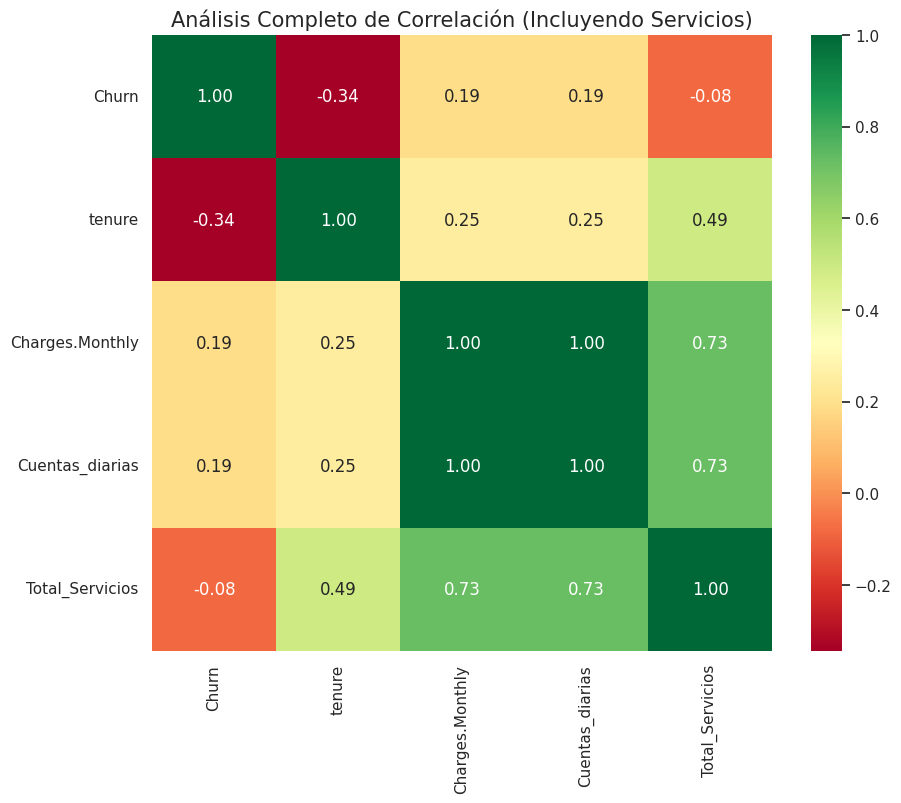

In [44]:
cols_para_corr = ['Churn', 'tenure', 'Charges.Monthly', 'Cuentas_diarias', 'Total_Servicios']
matriz_completa = df_final[cols_para_corr].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_completa, annot=True, cmap='RdYlGn', fmt=".2f")

plt.title('Análisis Completo de Correlación (Incluyendo Servicios)', fontsize=15)
plt.savefig('correlacion_total.png', dpi=300, bbox_inches='tight')
plt.show()

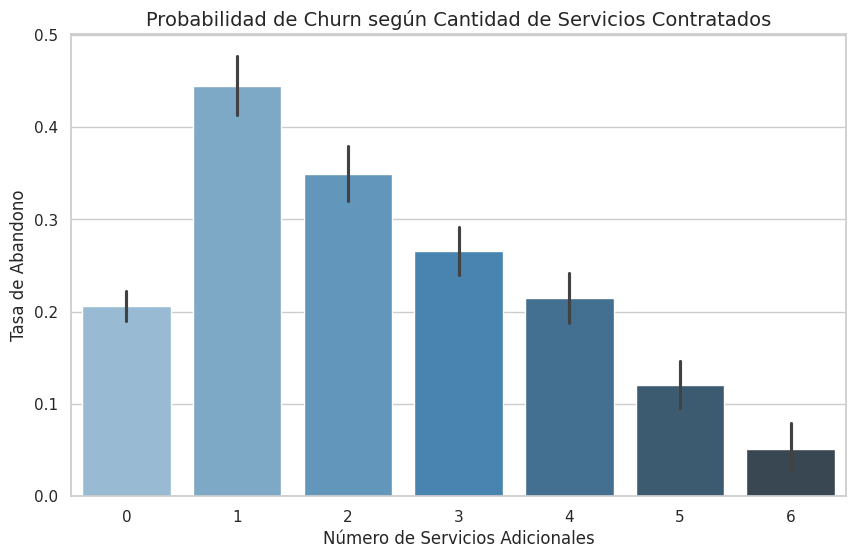

In [45]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Total_Servicios', y='Churn', data=df_final, palette='Blues_d')

plt.title('Probabilidad de Churn según Cantidad de Servicios Contratados', fontsize=14)
plt.xlabel('Número de Servicios Adicionales')
plt.ylabel('Tasa de Abandono')

plt.savefig('churn_servicios.png', dpi=300, bbox_inches='tight')
plt.show()

#📄Informe final

#**Reporte Ejecutivo: Proyecto - Telecom X**
##**1. Introducción**
Como parte del equipo de análisis de datos, se abordó la problemática de la alta tasa de evasión de clientes. El objetivo fue transformar los datos brutos de la API en información estratégica para reducir las cancelaciones, que actualmente afectan a 1,869 clientes frente a 5,398 que permanecen leales.

##**2. Limpieza y Tratamiento de Datos (Proceso ETL)**
El dataset fue sometido a un riguroso proceso de preparación:
* Normalización: Se transformaron estructuras complejas a un formato tabular.
* Características: Se crearon las métricas Cuentas_diarias y Total_Servicios para medir el impacto del costo diario y la profundidad de la relación con el cliente.
* Calidad de Datos: Se aseguraron los tipos numéricos para evitar errores de cálculo en promedios y correlaciones.

##**3. Análisis Exploratorio de Datos (EDA)**
A través de las visualizaciones estratégicas, hemos identificado los siguientes pilares del Churn:

* El Factor Tiempo y Dinero (Variables Numéricas)

Existe una correlación negativa de -0.34. El histograma muestra un "pico de fuga" crítico entre el mes 0 y el 5. Si un cliente supera el primer año, la probabilidad de abandono cae drásticamente.

Los clientes que cancelan tienen una mediana de pago cercana a los $80 USD, notablemente superior a la de los clientes leales.

La métrica Cuentas_diarias rectifica que un gasto diario elevado está directamente asociado con la insatisfacción.

* Comportamiento y Servicios (Variables Categóricas)

El contrato "Month-to-month" es el mayor generador de Churn. Los contratos a uno y dos años muestran una tasa de evasión casi nula.

El uso de "Electronic check" presenta una tasa de cancelación desproporcionadamente alta en comparación con métodos automáticos (tarjeta o transferencia).

El gráfico de "Probabilidad de Churn según Cantidad de Servicios" es contundente, es decir, un cliente con 1 servicio tiene un 45% de probabilidad de irse, mientras que uno con 6 servicios tiene menos del 5%.

##**4. Conclusiones**
No basta con vender internet, los servicios de OnlineSecurity y TechSupport son los que realmente "atan" al cliente a la empresa.

Los usuarios de fibra óptica tienen cargos más altos y, por ende, una mayor tendencia al Churn si no perciben un valor agregado.

Telecom X está perdiendo la batalla en los primeros 180 días de vida del cliente.

##**5. Recomendaciones Estratégicas**
Ofrecer descuentos agresivos en los meses 1 al 6 para asegurar que el cliente cruce la "barrera de lealtad" del primer año.

Incentivar el cambio de "Electronic check" a pagos automáticos mediante bonificaciones únicas.

Empaquetar internet con al menos 3 servicios adicionales de seguridad o soporte de forma gratuita por tiempo limitado para elevar el costo de salida del cliente.
